In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd
from sqlalchemy import create_engine
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot
import random
import json
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

db_username_0 = 'simulationuser'
db_password_0 = 'simulations2024'
db_host_0 = 'localhost'
db_port_0 = '5432'
db_name_0 = 'simulations_data'
table_name_0 = 'composite_data'

connection_string = f"postgresql://{db_username_0}:{db_password_0}@{db_host_0}:{db_port_0}/{db_name_0}"
engine = create_engine(connection_string)
query = f"SELECT * FROM {table_name_0}"
df = pd.read_sql(query, engine)


In [3]:

def average_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np_arrays, axis=0)
    
    return average_array

def average_eta_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np.abs(np_arrays), axis=0)
    
    return average_array

average_psi_e = average_arrays(*list(df['psi_e']))
average_b_e = average_arrays(*list(df['b_e']))
average_psi_plus = average_arrays(*list(df['psi_plus']))
average_b_plus = average_arrays(*list(df['b_plus']))
average_U = average_arrays(*list(df['u_list']))
average_R = average_arrays(*list(df['r_list']))
average_k_e_psi_e_list = average_arrays(*list(df['k_e_psi_e_list']))
average_k_e_b_e_list = average_arrays(*list(df['k_e_b_e_list']))
average_k_e_psi_plus_list = average_arrays(*list(df['k_e_psi_plus_list']))
average_k_e_b_plus_list = average_arrays(*list(df['k_e_b_plus_list']))
average_heat_flux_psi_e_b_e_list = average_arrays(*list(df['heat_flux_psi_e_b_e_list']))
average_heat_flux_psi_e_b_plus_list = average_arrays(*list(df['heat_flux_psi_e_b_plus_list']))
average_b_e_psi_plus_list = average_arrays(*list(df['b_e_psi_plus_list']))
average_b_e_b_plus_list = average_arrays(*list(df['b_e_b_plus_list']))
average_psi_plus_b_plus_list = average_arrays(*list(df['psi_plus_b_plus_list']))
average_eta = average_arrays(*list(df['eta_list']))

# average_eta = average_eta_arrays(*list(df['eta_list']))

# average_absolute_eta = [df['eta_list'].tolist()]


# window_size = 5000
# dt = .001
# epsilon = 0.12394270273516043
# N_0_squared = 318.8640217310387


In [4]:
epsilon = 0.12394270273516043
N_0_squared = 318.8640217310387
r_m = 0.1
k = 2 * np.pi * 6
m = 2 * np.pi * 3
m_u = 2 * np.pi * 7
dt = 0.001
total_time = 25

k_e_square = k**2 + m**2
k_plus_square = k**2 + (m + m_u)**2

def create_C_matrix(row):
    # Assume that all lists in the row have the same length
    length = len(row['k_e_psi_e_list'])  # The length of the lists in the row
    matrices = []
    
    for i in range(length):
        # Extracting the i-th element from each list in the row
        ke_psi_e = row['k_e_psi_e_list'][i]
        ke_b_e = row['k_e_b_e_list'][i]
        ke_psi_plus = row['k_e_psi_plus_list'][i]
        ke_b_plus = row['k_e_b_plus_list'][i]
        
        heat_flux_psi_e_b_e = row['heat_flux_psi_e_b_e_list'][i]
        heat_flux_psi_e_b_plus = row['heat_flux_psi_e_b_plus_list'][i]
        b_e_psi_plus = row['b_e_psi_plus_list'][i]
        b_e_b_plus = row['b_e_b_plus_list'][i]
        
        psi_plus_b_plus = row['psi_plus_b_plus_list'][i]
        psi_e_psi_plus = row['r_list'][i] 

        # Creating the C matrix for the i-th index
        C_matrix = np.array([
            [ke_psi_e, heat_flux_psi_e_b_e, psi_e_psi_plus/(0.25 * k * (k_plus_square - k_e_square)), heat_flux_psi_e_b_plus],
            [heat_flux_psi_e_b_e, ke_b_e, b_e_psi_plus, b_e_b_plus],
            [psi_e_psi_plus/(0.25 * k * (k_plus_square - k_e_square)), b_e_psi_plus, ke_psi_plus, psi_plus_b_plus],
            [heat_flux_psi_e_b_plus, b_e_b_plus, psi_plus_b_plus, ke_b_plus]
        ])
        
        matrices.append(C_matrix)

    return matrices  # This returns a list of matrices for the row

In [5]:
df['C_Matrix'] = df.apply(create_C_matrix, axis = 1)
df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list,C_Matrix
0,1500,0.123943,318.864022,"[-0.011744609035812982, -0.011215305626181015,...","[-5.517162102724528, -3.1920707854231463, -0.9...","[-0.0016475367466768115, -0.002355776502265530...","[10.73076649947905, 10.77581128940965, 10.5402...","[0.4615413218450946, 0.4686702377764153, 0.478...","[0.6551578220909112, 0.8945764375320215, 1.175...","[0.00013793584140409996, 0.0001257830802886475...","[30.43907766773974, 10.189315899151941, 0.8663...","[2.7143773316504123e-06, 5.549682928626416e-06...","[115.14934966634185, 116.11810894496844, 111.0...","[0.06479691188370344, 0.035800049438924265, 0....","[-0.1260286571909809, -0.12085401698078094, -0...","[0.009089727301611367, 0.007519805349868124, 0...","[-59.203378264111755, -34.39715240615747, -9.8...","[-0.01767933212790023, -0.025385403028438877, ...","[[1.0369206541904592], [-1.6813054180526377], ...","[[[0.00013793584140409996, 0.06479691188370344..."
1,1501,0.123943,318.864022,"[-0.008147157474100065, -0.008292099833020762,...","[-0.832904729882089, 0.14071461474575664, 1.27...","[0.0006807256129005129, 0.0007313699095774325,...","[-0.7190970906032216, -0.6095182673572732, -0....","[0.23703131704960073, 0.23479400902756253, 0.2...","[-0.18778048603775238, -0.2053401462453807, -0...","[6.637617490778455e-05, 6.875891964078295e-05,...","[0.6937302890599556, 0.019800602803046713, 1.6...","[4.6338736005877887e-07, 5.349019446353018e-07...","[0.5171006257140178, 0.3715125182422124, 0.293...","[0.006785805995272157, -0.0011668196334368695,...","[0.005858597236311648, 0.005054186322976349, 0...","[-0.0005669795827367211, 0.0001029144350628272...","[0.5989393680078723, -0.0857681281716798, -0.6...","[-0.0004895078077358536, -0.000445783320082882...","[[1.418213787060706], [0.8827834628841255], [0...","[[[6.637617490778455e-05, 0.006785805995272157..."
2,1502,0.123943,318.864022,"[-0.003781434990007615, -0.001308768972368787,...","[7.429632504232679, 7.616174400779771, 7.45893...","[0.0017201097552821953, 0.0016973192181066884,...","[0.26192796713213556, -0.016191321040263613, -...","[0.3398928494975913, 0.33847860008307173, 0.33...","[-0.22023434840890527, -0.0752140155360062, 0....","[1.4299250583653892e-05, 1.7128762230352505e-0...","[55.199439147950756, 58.00611250309311, 55.635...","[2.958777570216974e-06, 2.8808925281543e-06, 2...","[0.06860625996597308, 0.0002621588770288832, 0...","[-0.028094672314403355, -0.009967812743890003,...","[-0.000990463579775022, 2.1190698599158928e-05...","[0.012779783348692317, 0.012927079178895698, 0...","[1.9460285383725033, -0.12331592482166262, -2....","[0.00045054485144522063, -2.7481840368174608e-...","[[-0.6679438799496836], [-0.8041216677662598],...","[[[1.4299250583653892e-05, -0.0280946723144033..."
3,1503,0.123943,318.864022,"[-0.008102021680746106, -0.007577287179778589,...","[-13.405475487140006, -12.142974722866745, -10...","[-0.007065355563569785, -0.007211423776971252,...","[3.432058579711073, 2.9279736455346024, 2.4210...","[0.15021463519080008, 0.17082991418834997, 0.1...","[1.9382048681079675, 1.850150346137473, 2.4148...","[6.564275531527996e-05, 5.7415281004836965e-05...","[179.70677303631157, 147.4518351201807, 119.05...","[4.991924923966652e-05, 5.2004632891066315e-05...","[11.779026094568387, 8.573029668945189, 5.8616...","[0.10861145303751879, 0.09201080669195365, 0.1...","[-0.0278066130224098, -0.022186097167038923, -...","[0.09471445081536302, 0.08756813663964214, 0.0...","[-46.00837716074533, -35.55430996694667, -26.4...","[-0.024248714180659044, -0.021114858765753426,...","[[0.20668630436664126], [1.0343110874926529], ...","[[[6.564275531527996e-05, 0.10861145303751879,..."
4,1504,0.123943,318.864022,"[-0.0007052290130828054, -0.003475921446700475...","[7.188510348955567, 7.255315

In [6]:
C_Mat_Arr = df['C_Matrix']
C_Mat_Arr

0        [[[0.00013793584140409996, 0.06479691188370344...
1        [[[6.637617490778455e-05, 0.006785805995272157...
2        [[[1.4299250583653892e-05, -0.0280946723144033...
3        [[[6.564275531527996e-05, 0.10861145303751879,...
4        [[[4.973479608937477e-07, -0.00506954605892946...
                               ...                        
10709    [[[0.0003056710719046377, -0.0570755958620275,...
10710    [[[1.1021618834990386e-05, 0.00883054898021900...
10711    [[[3.5137087587202417e-05, 0.05941200551124365...
10712    [[[1.085442426508469e-05, -0.02696846172903942...
10713    [[[6.07039887848946e-06, 0.058191941293165794,...
Name: C_Matrix, Length: 10714, dtype: object

In [7]:
average_C_Mat = np.mean(C_Mat_Arr.tolist(), axis = 0)
average_C_Mat

array([[[ 9.39898981e-05, -6.82344367e-03,  1.87794274e-06,
         -1.28853191e-02],
        [-6.82344367e-03,  5.66651146e+01,  2.70094602e-03,
         -4.93601380e+00],
        [ 1.87794274e-06,  2.70094602e-03,  9.70537008e-06,
         -1.32725831e-03],
        [-1.28853191e-02, -4.93601380e+00, -1.32725831e-03,
          1.90495941e+01]],

       [[ 9.37136546e-05, -6.91374314e-03,  1.91326107e-06,
         -1.27231756e-02],
        [-6.91374314e-03,  5.67573860e+01,  2.64596164e-03,
         -4.87414655e+00],
        [ 1.91326107e-06,  2.64596164e-03,  9.70273829e-06,
         -1.37877204e-03],
        [-1.27231756e-02, -4.87414655e+00, -1.37877204e-03,
          1.90064927e+01]],

       [[ 9.29921373e-05, -6.95811210e-03,  1.87605687e-06,
         -1.27049457e-02],
        [-6.95811210e-03,  5.68503202e+01,  2.58977068e-03,
         -4.85255601e+00],
        [ 1.87605687e-06,  2.58977068e-03,  9.70642957e-06,
         -1.41954025e-03],
        [-1.27049457e-02, -4.85255601e+

In [8]:
average_C_Mat.shape

(1000, 4, 4)

In [9]:
average_C_Mat[0]

array([[ 9.39898981e-05, -6.82344367e-03,  1.87794274e-06,
        -1.28853191e-02],
       [-6.82344367e-03,  5.66651146e+01,  2.70094602e-03,
        -4.93601380e+00],
       [ 1.87794274e-06,  2.70094602e-03,  9.70537008e-06,
        -1.32725831e-03],
       [-1.28853191e-02, -4.93601380e+00, -1.32725831e-03,
         1.90495941e+01]])

In [10]:

class Simulation:
    def __init__(self, epsilon, N_0_squared, r_m, k, m, m_u, dt, total_time, U, C, current_time):

        #Make sure this is updated

        self.epsilon = epsilon
        self.N_0_squared = N_0_squared
        self.r_m = r_m
        self.k = k
        self.m = m
        self.m_u = m_u
        self.dt = dt
        self.total_time = total_time
        self.num_steps = int(total_time / dt)
        self.k_e_square = k**2 + m**2
        self.k_plus_square = k**2 + (m + m_u)**2

        self.W_e = np.array([[-1, (k / self.k_e_square)], [-k * N_0_squared, -1]])
        self.W_plus = np.array([[-1, -k / self.k_plus_square], [k * N_0_squared, -1]])
        self.L_e_plus = np.array([[(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), 0],
                                  [0, k / 2]])
        self.L_plus_e = np.array([[(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), 0],
                                  [0, -k / 2]]) 
        self.U = U
        # self.C = np.array([[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])
        self.C = C

        self.current_time = current_time

        self.A_U = np.array([[-1, (k / self.k_e_square), self.U*(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), self.U*0],
                             
                             [-k * N_0_squared, -1, self.U*0, self.U*self.k/2],

                             [self.U*(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), self.U*0, -1, -self.k/self.k_plus_square],

                             [self.U*0, self.U* -k / 2,k * N_0_squared, -1]])  
    
        self.Q = np.array([[8/self.k_e_square, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])
        self.R = 0
        self.C_History = np.zeros((self.num_steps, 4, 4))              
        # self.C_History = np.zeros(self.num_steps)
        self.U_History = np.zeros(self.num_steps)
        self.R_History = np.zeros(self.num_steps)
        self.C = self.C.astype(np.float64)

    def simulate(self):
        for i in range(self.num_steps):

            self.A_U = np.array([[-1, (k / self.k_e_square), self.U*(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), self.U*0],
                             
                             [-k * N_0_squared, -1, self.U*0, self.U*self.k/2],

                             [self.U*(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), self.U*0, -1, -self.k/self.k_plus_square],

                             [self.U*0, self.U* -k / 2,k * N_0_squared, -1]]) 
                             
 
            C_dot = (self.A_U @ self.C + self.C @ np.transpose(self.A_U) + self.epsilon * self.Q) 
            U_dot = (self.R - self.r_m * self.U)

            
            self.C += C_dot * self.dt
            self.U += U_dot * self.dt
            self.R = 0.25 * self.k * (self.k_plus_square - self.k_e_square) * self.C[0][2]

            self.C_History[i] = self.C
            self.U_History[i] = self.U
            self.R_History[i] = self.R


In [11]:

def make_plots(sims):

    n_sims = len(sims)

    fig, axs = plt.subplots(n_sims, 2, figsize=(10, 2.4 * n_sims))

    # If there is only one sim, make axs behave like a 2D array
    if n_sims == 1:
        axs = np.array([axs])

    for i in range(n_sims):

        # Build a time array that matches the actual history length
        time_array_U = np.arange(len(sims[i].U_History)) * sims[i].dt
        time_array_R = np.arange(len(sims[i].R_History)) * sims[i].dt

        # ----------------------------
        # U History Plot
        # ----------------------------
        axs[i, 0].plot(
            time_array_U,
            sims[i].U_History,
            color='red'
        )

        axs[i, 0].set_xlabel('Time')
        axs[i, 0].set_ylabel('Jet Velocity')
        axs[i, 0].set_ylim(-0.5, 0.5)
        axs[i, 0].grid(True)

        # ----------------------------
        # R History Plot
        # ----------------------------
        axs[i, 1].plot(
            time_array_R,
            sims[i].R_History,
            color='red'
        )

        axs[i, 1].set_xlabel('Time')
        axs[i, 1].set_ylabel('Reynolds Stress')
        axs[i, 1].set_ylim(-3.75, 3.75)
        axs[i, 1].grid(True)

        # ----------------------------
        # Titles
        # ----------------------------
        relative_time = int((sims[i].current_time + 1) // 100 - 5)

        if relative_time < 0:
            title = f"T=T{relative_time}"
        elif relative_time == 0:
            title = "T=0 (Time of Reversal)"
        else:
            title = f"T=T+{relative_time}"

        axs[i, 0].set_title(title)
        axs[i, 1].set_title(title)

    plt.tight_layout()
    plt.show()

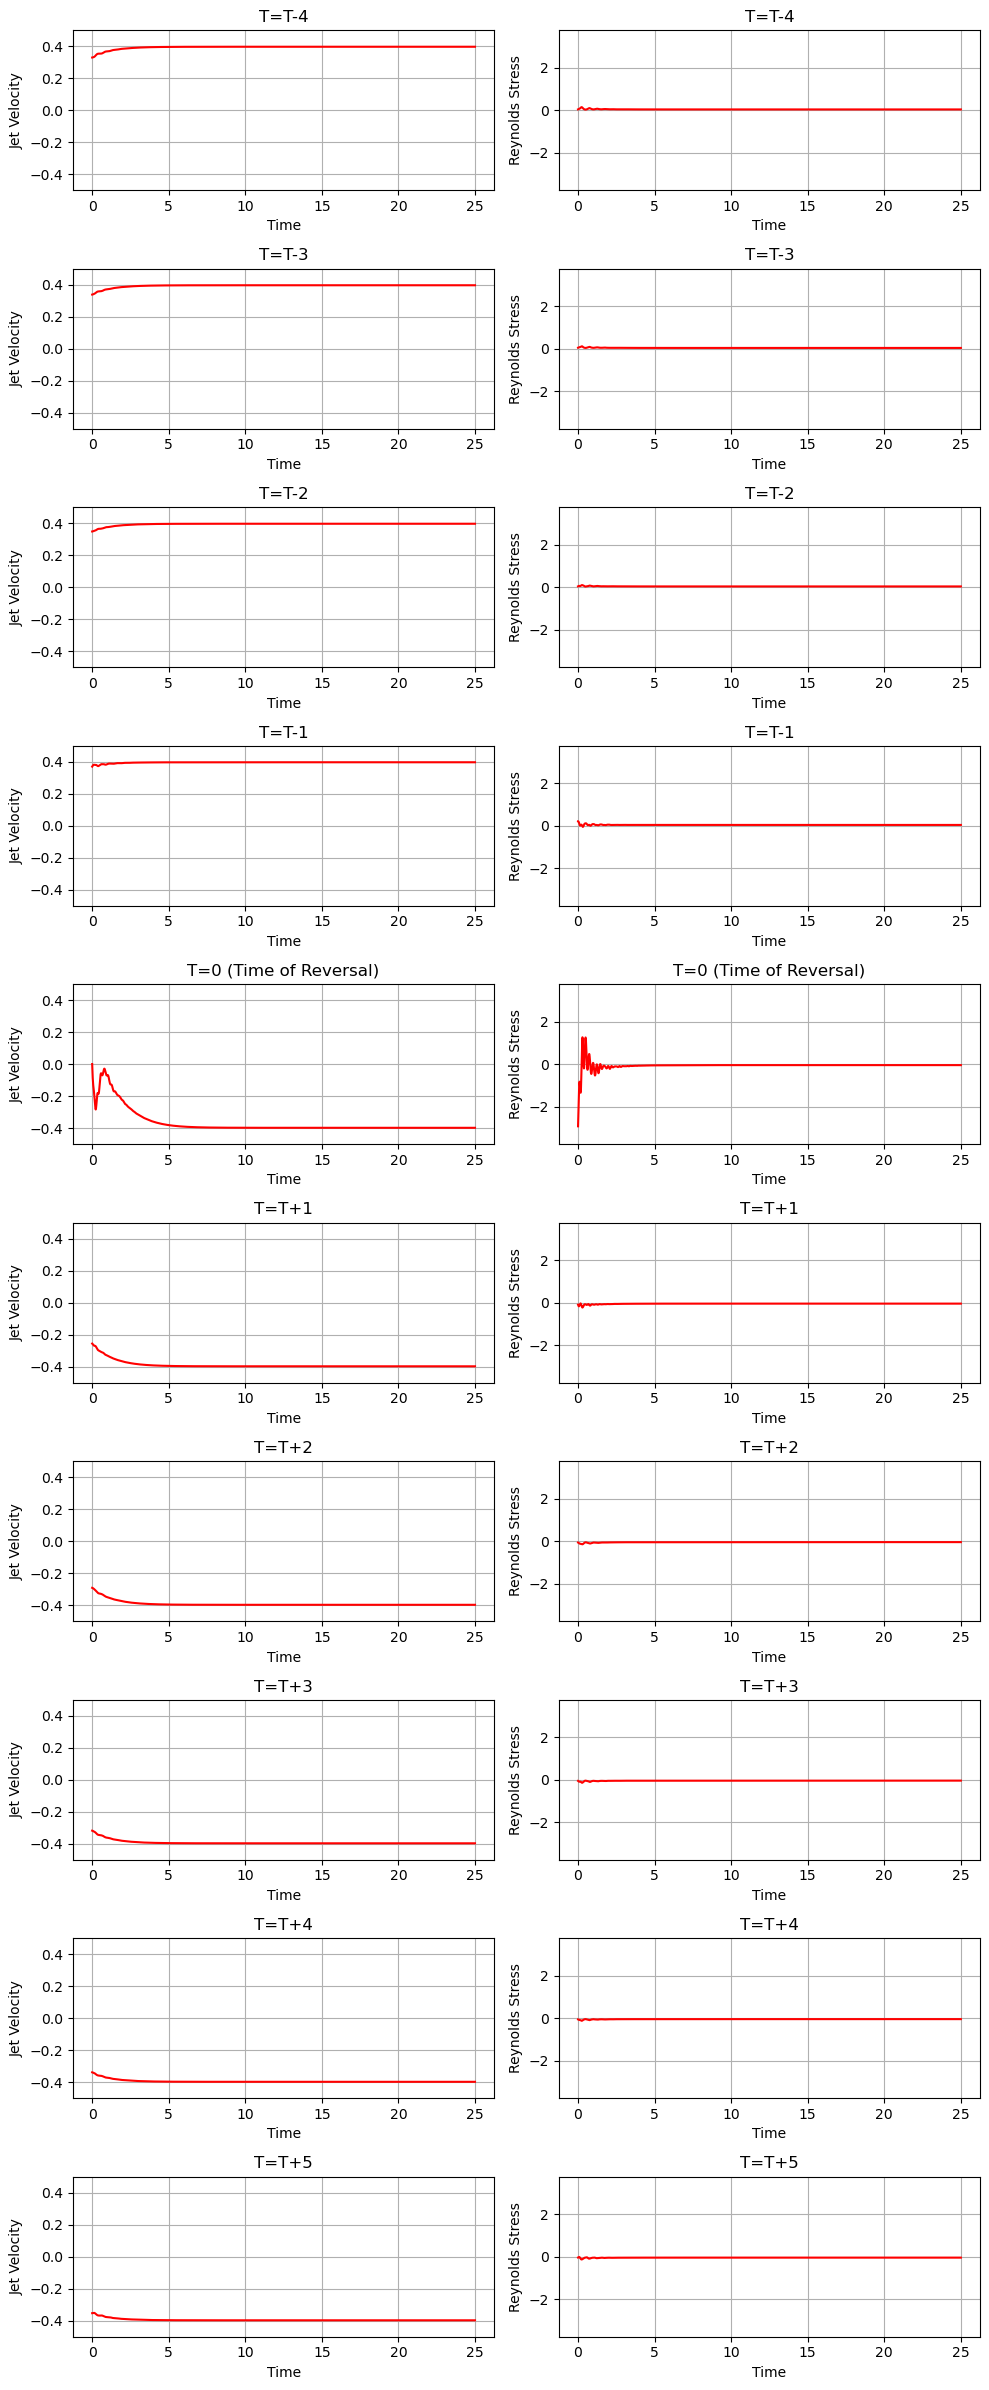

In [12]:


if __name__ == "__main__":
    epsilon = 0.12394270273516043
    N_0_squared = 318.8640217310387
    r_m = 0.1
    k = 2 * np.pi * 6
    m = 2 * np.pi * 3
    m_u = 2 * np.pi * 7
    dt = 0.001
    total_time = 25

    k_e_square = k**2 + m**2

    C_11 = (2*epsilon/k_e_square)*(2-(np.square(k) * N_0_squared/(k_e_square + np.square(k)*N_0_squared)))
    C_12 = -(2*epsilon*k*N_0_squared)/(k_e_square + np.square(k)*N_0_squared)
    C_22 = (2*epsilon*np.square(k)*np.square(N_0_squared))/(k_e_square + np.square(k)*N_0_squared)


#     U_entries = np.array([0.5022827801804544, 0.40950991628144395, 0.36386063053663087, 0.3794275046949516, 0.0021052785076200523, -0.21572820861504546, -0.33933857396878414, -0.44582272206193174, -0.37404536864576843, -0.33003068506849215])
#     C_entries = np.array([[[3.209225737451153e-05,
#   0.004308328634512763,
#   -2.2865617299652913e-06,
#   -0.04298516464145379],
#  [0.004308328634512763,
#   0.5783854780407179,
#   -0.00030696685685982993,
#   -5.770682115715138],
#  [-2.2865617299652913e-06,
#   -0.00030696685685982993,
#   1.6291669619645895e-07,
#   0.003062677432702768],
#  [-0.04298516464145379,
#   -5.770682115715138,
#   0.003062677432702768,
#   57.57539451619873]], [[4.674061556047324e-06,
#   -0.015152332601359049,
#   -5.253684734195421e-06,
#   -0.010543186474467389],
#  [-0.015152332601359049,
#   49.120701665804866,
#   0.017031350041211486,
#   34.17881134504736],
#  [-5.253684734195421e-06,
#   0.017031350041211486,
#   5.905186090373037e-06,
#   0.011850630798608194],
#  [-0.010543186474467389,
#   34.17881134504736,
#   0.011850630798608194,
#   23.782053296147613]], [[4.2902852820799504e-05,
#   -0.05776262630394941,
#   -1.1623135158089199e-05,
#   0.020913647682537603],
#  [-0.05776262630394941,
#   77.76921062722774,
#   0.015648908370296363,
#   -28.15727011871854],
#  [-1.1623135158089199e-05,
#   0.015648908370296363,
#   3.148911133427319e-06,
#   -0.005665873891373166],
#  [0.020913647682537603,
#   -28.15727011871854,
#   -0.005665873891373166,
#   10.194675426741465]], [[0.00014732175533658907,
#   -0.10022658170538411,
#   4.334461987889665e-06,
#   0.003599936287279282],
#  [-0.10022658170538411,
#   68.18658695312973,
#   -0.002948840159999165,
#   -2.4491244189076187],
#  [4.334461987889665e-06,
#   -0.002948840159999165,
#   1.275274020563772e-07,
#   0.00010591637983396548],
#  [0.003599936287279282,
#   -2.4491244189076187,
#   0.00010591637983396548,
#   0.08796760018818137]], [[0.00037464754867079866,
#   -0.43371234047679336,
#   -0.0001046607960770223,
#   -0.07335717575778004],
#  [-0.43371234047679336,
#   502.0889498656411,
#   0.1211610191599468,
#   84.92224892850105],
#  [-0.0001046607960770223,
#   0.1211610191599468,
#   2.9237832395644953e-05,
#   0.02049291511451366],
#  [-0.07335717575778004,
#   84.92224892850105,
#   0.02049291511451366,
#   14.36356718267584]], [[0.000502036223101408,
#   -0.03506758548396667,
#   2.044096583350114e-05,
#   0.04254621386930327],
#  [-0.03506758548396667,
#   2.4494956640348073,
#   -0.001427815929920163,
#   -2.971883149514389],
#  [2.044096583350114e-05,
#   -0.001427815929920163,
#   8.322767660571007e-07,
#   0.001732316641764691],
#  [0.04254621386930327,
#   -2.971883149514389,
#   0.001732316641764691,
#   3.6056767048198615]], [[2.6475415454580633e-05,
#   -0.026549380836582464,
#   3.691906861667028e-06,
#   0.0009266904809122064],
#  [-0.026549380836582464,
#   26.623552858504414,
#   -0.0037022210832439034,
#   -0.9292794115953044],
#  [3.691906861667028e-06,
#   -0.0037022210832439034,
#   5.148238862807293e-07,
#   0.00012922384356878395],
#  [0.0009266904809122064,
#   -0.9292794115953044,
#   0.00012922384356878395,
#   0.03243594983000424]], [[2.3132908740317164e-06,
#   -0.013119841309147893,
#   -3.2784103608848675e-06,
#   0.006064271697738729],
#  [-0.013119841309147893,
#   74.40924870689803,
#   0.018593521534156204,
#   -34.393548698536115],
#  [-3.2784103608848675e-06,
#   0.018593521534156204,
#   4.646183761415681e-06,
#   -0.008594323951331568],
#  [0.006064271697738729,
#   -34.393548698536115,
#   -0.008594323951331568,
#   15.89743496454513]], [[0.00025615893953517414,
#   -0.1361574153724205,
#   -9.749944394245619e-06,
#   -0.03861531552553974],
#  [-0.1361574153724205,
#   72.37241766591642,
#   0.005182435682917152,
#   20.525387735008287],
#  [-9.749944394245619e-06,
#   0.005182435682917152,
#   3.711032527827448e-07,
#   0.0014697795822525405],
#  [-0.03861531552553974,
#   20.525387735008287,
#   0.0014697795822525405,
#   5.821161642232034]], [[0.00010069930425200607,
#   0.10780210165882807,
#   -9.21441099886821e-06,
#   -0.010822046507882056],
#  [0.10780210165882807,
#   115.40589290445659,
#   -0.009864346914853939,
#   -11.585376547187273],
#  [-9.21441099886821e-06,
#   -0.009864346914853939,
#   8.431574645598605e-07,
#   0.0009902628932066844],
#  [-0.010822046507882056,
#   -11.585376547187273,
#   0.0009902628932066844,
#   1.163033761640206]]])

    # U_entries = np.array([average_U[99], average_U[199], average_U[299], average_U[399], average_U[499], average_U[599], average_U[699], average_U[799], average_U[899], average_U[999]])
    # C_entries = np.array([average_C_Mat[99], average_C_Mat[199], average_C_Mat[299], average_C_Mat[399], average_C_Mat[499], average_C_Mat[599], average_C_Mat[699], average_C_Mat[799], average_C_Mat[899], average_C_Mat[999]])
    
    # current_time_entries = np.array([99, 199, 299, 399, 499 ,599, 699, 799, 899, 999])

    indices = np.arange(99, 1000, 100)

    U_entries = np.array([average_U[i] for i in indices])
    C_entries = np.array([average_C_Mat[i] for i in indices])

    current_time_entries = indices

    sims = [Simulation(epsilon, N_0_squared, r_m, k, m, m_u, dt, total_time, U_entries[i], C_entries[i], current_time_entries[i]) for i in range(10)]
    for i in sims:
        i.simulate()
    make_plots(sims)
    



In [13]:
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML
# import matplotlib.pyplot as plt
# import numpy as np




# def run_from_all_saved_states(
#     average_U,
#     average_C_Mat,
#     epsilon,
#     N_0_squared,
#     r_m,
#     k,
#     m,
#     m_u,
#     dt,
#     total_time,
#     max_start_index=1000
# ):
#     indices = np.arange(max_start_index)

#     U_entries = average_U[indices]
#     C_entries = average_C_Mat[indices]
#     current_time_entries = indices

#     all_U_histories = []
#     all_C_histories = []
#     all_R_histories = []

#     for U0, C0, current_time in zip(U_entries, C_entries, current_time_entries):
#         sim = Simulation(
#             epsilon=epsilon,
#             N_0_squared=N_0_squared,
#             r_m=r_m,
#             k=k,
#             m=m,
#             m_u=m_u,
#             dt=dt,
#             total_time=total_time,
#             U=U0,
#             C=C0.copy(),
#             current_time=current_time
#         )

#         sim.simulate()

#         all_U_histories.append(sim.U_History)
#         all_C_histories.append(sim.C_History)
#         all_R_histories.append(sim.R_History)

#     return (
#         np.array(all_U_histories),
#         np.array(all_C_histories),
#         np.array(all_R_histories),
#         current_time_entries
#     )

# all_U_histories, all_C_histories, all_R_histories, current_time_entries = run_from_all_saved_states(
#     average_U=average_U,
#     average_C_Mat=average_C_Mat,
#     epsilon=epsilon,
#     N_0_squared=N_0_squared,
#     r_m=r_m,
#     k=k,
#     m=m,
#     m_u=m_u,
#     dt=dt,
#     total_time=total_time,
#     max_start_index=1000
# )

# def animate_restart_full_trajectory(
#     all_U_histories,
#     current_time_entries,
#     dt,
#     interval=50
# ):
#     num_restarts, num_steps = all_U_histories.shape
#     future_time = np.arange(num_steps) * dt

#     fig, ax = plt.subplots(figsize=(8, 5))

#     line, = ax.plot([], [], lw=2)

#     ax.set_xlim(future_time[0], future_time[-1])
#     ax.set_ylim(np.min(all_U_histories), np.max(all_U_histories))

#     ax.set_xlabel("Time after restart")
#     ax.set_ylabel("U")
#     ax.set_title("Full Future Evolution from Each Saved State")

#     text = ax.text(
#         0.02,
#         0.95,
#         "",
#         transform=ax.transAxes,
#         verticalalignment="top"
#     )

#     def init():
#         line.set_data([], [])
#         text.set_text("")
#         return line, text

#     def update(restart_index):
#         line.set_data(future_time, all_U_histories[restart_index])

#         text.set_text(
#             f"Restart simulation: {restart_index}\n"
#             f"Initial state: U[{restart_index}], C[{restart_index}]"
#         )

#         return line, text

#     anim = FuncAnimation(
#         fig,
#         update,
#         frames=num_restarts,
#         init_func=init,
#         interval=interval,
#         blit=True
#     )

#     plt.close(fig)
#     return anim

# anim = animate_restart_full_trajectory(
#     all_U_histories=all_U_histories,
#     current_time_entries=current_time_entries,
#     dt=dt
# )

# html_animation = anim.to_jshtml()

# with open("restart_animation.html", "w") as f:
#     f.write(html_animation)



In [14]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib as mpl

# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML, display


# # ============================================================
# # Settings
# # ============================================================

# mpl.rcParams["animation.embed_limit"] = 300  # MB, because 20 MB is apparently a legal boundary now

# MAX_START_INDEX = 1000
# ANIMATION_INTERVAL = 50

# SAVE_HTML_FILES = True
# DISPLAY_U_ANIMATION = False
# DISPLAY_C_ANIMATION = False

# U_HTML_FILENAME = "restart_U_animation.html"
# C_HTML_FILENAME = "restart_C_matrix_elements_animation.html"


# # ============================================================
# # Run restarted simulations from every saved state
# # ============================================================

# def run_from_all_saved_states(
#     average_U,
#     average_C_Mat,
#     epsilon,
#     N_0_squared,
#     r_m,
#     k,
#     m,
#     m_u,
#     dt,
#     total_time,
#     max_start_index=1000
# ):
#     indices = np.arange(max_start_index)

#     U_entries = average_U[indices]
#     C_entries = average_C_Mat[indices]
#     current_time_entries = indices

#     all_U_histories = []
#     all_C_histories = []
#     all_R_histories = []

#     for restart_index, (U0, C0, current_time) in enumerate(
#         zip(U_entries, C_entries, current_time_entries)
#     ):
#         sim = Simulation(
#             epsilon=epsilon,
#             N_0_squared=N_0_squared,
#             r_m=r_m,
#             k=k,
#             m=m,
#             m_u=m_u,
#             dt=dt,
#             total_time=total_time,
#             U=U0,
#             C=C0.copy(),
#             current_time=current_time
#         )

#         sim.simulate()

#         all_U_histories.append(sim.U_History)
#         all_C_histories.append(sim.C_History)
#         all_R_histories.append(sim.R_History)

#         if restart_index % 100 == 0:
#             print(f"Finished restart simulation {restart_index}/{max_start_index - 1}")

#     return (
#         np.array(all_U_histories),
#         np.array(all_C_histories),
#         np.array(all_R_histories),
#         current_time_entries
#     )


# # Basic checks, because silent shape errors are how notebooks become crime scenes
# print("average_U shape:", np.shape(average_U))
# print("average_C_Mat shape:", np.shape(average_C_Mat))

# assert len(average_U) >= MAX_START_INDEX, "average_U has fewer than MAX_START_INDEX entries."
# assert len(average_C_Mat) >= MAX_START_INDEX, "average_C_Mat has fewer than MAX_START_INDEX entries."
# assert np.shape(average_C_Mat[0]) == (4, 4), "Each average_C_Mat entry must be a 4x4 matrix."


# all_U_histories, all_C_histories, all_R_histories, current_time_entries = run_from_all_saved_states(
#     average_U=average_U,
#     average_C_Mat=average_C_Mat,
#     epsilon=epsilon,
#     N_0_squared=N_0_squared,
#     r_m=r_m,
#     k=k,
#     m=m,
#     m_u=m_u,
#     dt=dt,
#     total_time=total_time,
#     max_start_index=MAX_START_INDEX
# )

# print("all_U_histories shape:", all_U_histories.shape)
# print("all_C_histories shape:", all_C_histories.shape)
# print("all_R_histories shape:", all_R_histories.shape)


# # ============================================================
# # Animation 1: U trajectory for each restart
# # ============================================================

# def animate_restart_U_full_trajectory(
#     all_U_histories,
#     current_time_entries,
#     dt,
#     interval=50
# ):
#     num_restarts, num_steps = all_U_histories.shape
#     future_time = np.arange(num_steps) * dt

#     fig, ax = plt.subplots(figsize=(8, 5))

#     line, = ax.plot([], [], lw=2)

#     y_min = np.nanmin(all_U_histories)
#     y_max = np.nanmax(all_U_histories)
#     padding = 0.05 * (y_max - y_min) if y_max > y_min else 1.0

#     ax.set_xlim(future_time[0], future_time[-1])
#     ax.set_ylim(y_min - padding, y_max + padding)

#     ax.set_xlabel("Time after restart")
#     ax.set_ylabel("U")
#     ax.set_title("Full Future Evolution from Each Saved State")

#     text = ax.text(
#         0.02,
#         0.95,
#         "",
#         transform=ax.transAxes,
#         verticalalignment="top"
#     )

#     def init():
#         line.set_data([], [])
#         text.set_text("")
#         return line, text

#     def update(restart_index):
#         saved_index = current_time_entries[restart_index]

#         line.set_data(future_time, all_U_histories[restart_index])

#         text.set_text(
#             f"Restart simulation: {restart_index}\n"
#             f"Initial state: U[{saved_index}], C[{saved_index}]"
#         )

#         return line, text

#     anim = FuncAnimation(
#         fig,
#         update,
#         frames=num_restarts,
#         init_func=init,
#         interval=interval,
#         blit=True
#     )

#     plt.close(fig)
#     return anim


# # ============================================================
# # Animation 2: C matrix element grid for each restart
# # ============================================================

# def animate_C_matrix_elements_full_trajectory(
#     all_C_histories,
#     current_time_entries,
#     dt,
#     interval=50
# ):
#     elements = [
#         (0, 0), (0, 1), (0, 2), (0, 3),
#         (1, 1), (1, 2), (1, 3),
#         (2, 2), (2, 3),
#         (3, 3)
#     ]

#     num_restarts, num_steps, _, _ = all_C_histories.shape
#     future_time = np.arange(num_steps) * dt

#     nrows = 4
#     ncols = 3

#     fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10))
#     axes = axes.flatten()

#     lines = []

#     for plot_index, (row, col) in enumerate(elements):
#         ax = axes[plot_index]

#         line, = ax.plot([], [], lw=1.8)
#         lines.append(line)

#         data = all_C_histories[:, :, row, col]

#         y_min = np.nanmin(data)
#         y_max = np.nanmax(data)
#         padding = 0.05 * (y_max - y_min) if y_max > y_min else 1.0

#         ax.set_xlim(future_time[0], future_time[-1])
#         ax.set_ylim(y_min - padding, y_max + padding)

#         ax.set_title(f"C[{row}, {col}]")
#         ax.set_xlabel("Time after restart")
#         ax.set_ylabel(f"C[{row}, {col}]")

#     for plot_index in range(len(elements), len(axes)):
#         axes[plot_index].axis("off")

#     title = fig.suptitle("", fontsize=14)

#     plt.tight_layout(rect=[0, 0, 1, 0.95])

#     def init():
#         for line in lines:
#             line.set_data([], [])

#         title.set_text("")
#         return lines + [title]

#     def update(restart_index):
#         saved_index = current_time_entries[restart_index]

#         for line, (row, col) in zip(lines, elements):
#             y = all_C_histories[restart_index, :, row, col]
#             line.set_data(future_time, y)

#         title.set_text(
#             f"C Matrix Elements from Restart Simulation {restart_index} "
#             f"| Initial state: U[{saved_index}], C[{saved_index}]"
#         )

#         return lines + [title]

#     anim = FuncAnimation(
#         fig,
#         update,
#         frames=num_restarts,
#         init_func=init,
#         interval=interval,
#         blit=True
#     )

#     plt.close(fig)
#     return anim


# # ============================================================
# # Create animations
# # ============================================================

# anim_U = animate_restart_U_full_trajectory(
#     all_U_histories=all_U_histories,
#     current_time_entries=current_time_entries,
#     dt=dt,
#     interval=ANIMATION_INTERVAL
# )

# anim_C = animate_C_matrix_elements_full_trajectory(
#     all_C_histories=all_C_histories,
#     current_time_entries=current_time_entries,
#     dt=dt,
#     interval=ANIMATION_INTERVAL
# )


# # ============================================================
# # Convert to HTML and save
# # ============================================================

# # ============================================================
# # Convert animations to HTML
# # ============================================================

# print("Converting U animation to HTML...")
# html_animation_U = anim_U.to_jshtml()

# print("Converting C animation to HTML...")
# html_animation_C = anim_C.to_jshtml()


# # ============================================================
# # Save U and C animations together in one labeled HTML file
# # ============================================================

# combined_html_filename = "restart_U_and_C_animations.html"

# combined_html = f"""
# <!DOCTYPE html>
# <html>
# <head>
#     <meta charset="UTF-8">
#     <title>Restart Simulation Animations</title>

#     <style>
#         body {{
#             font-family: Arial, sans-serif;
#             margin: 30px;
#             background-color: #ffffff;
#             color: #111111;
#         }}

#         h1 {{
#             text-align: center;
#             margin-bottom: 40px;
#         }}

#         h2 {{
#             border-bottom: 2px solid #222222;
#             padding-bottom: 8px;
#             margin-top: 50px;
#         }}

#         .section {{
#             margin-bottom: 70px;
#         }}

#         .description {{
#             font-size: 16px;
#             margin-bottom: 20px;
#             line-height: 1.5;
#         }}

#         .animation-box {{
#             border: 1px solid #cccccc;
#             padding: 20px;
#             margin-top: 20px;
#         }}
#     </style>
# </head>

# <body>

#     <h1>Restart Simulation Animations</h1>

#     <div class="section">
#         <h2>Animation 1: U Evolution</h2>

#         <div class="description">
#             This animation shows the future evolution of <b>U</b> after restarting
#             the simulation from each saved state.
#             <br><br>
#             Frame 0 starts from <code>average_U[0]</code> and <code>average_C_Mat[0]</code>.
#             Frame 1 starts from <code>average_U[1]</code> and <code>average_C_Mat[1]</code>.
#             This continues through the selected restart indices.
#         </div>

#         <div class="animation-box">
#             {html_animation_U}
#         </div>
#     </div>

#     <div class="section">
#         <h2>Animation 2: C Matrix Element Evolution</h2>

#         <div class="description">
#             This animation shows the future evolution of selected <b>C matrix elements</b>
#             after restarting the simulation from each saved state.
#             <br><br>
#             The displayed elements are:
#             <code>C[0,0]</code>, <code>C[0,1]</code>, <code>C[0,2]</code>, <code>C[0,3]</code>,
#             <code>C[1,1]</code>, <code>C[1,2]</code>, <code>C[1,3]</code>,
#             <code>C[2,2]</code>, <code>C[2,3]</code>, and <code>C[3,3]</code>.
#         </div>

#         <div class="animation-box">
#             {html_animation_C}
#         </div>
#     </div>

# </body>
# </html>
# """

# with open(combined_html_filename, "w") as f:
#     f.write(combined_html)

# print(f"Saved combined U and C animation file to: {combined_html_filename}")


# # ============================================================
# # Display animations in notebook
# # ============================================================

# if DISPLAY_U_ANIMATION:
#     print("Displaying U animation...")
#     display(HTML(html_animation_U))

# if DISPLAY_C_ANIMATION:
#     print("Displaying C matrix animation...")
#     display(HTML(html_animation_C))


# # ============================================================
# # Bonus: static heatmaps, because waiting for animations is medieval
# # ============================================================

# # plt.figure(figsize=(9, 6))
# # plt.imshow(
# #     all_U_histories,
# #     aspect="auto",
# #     origin="lower",
# #     extent=[
# #         0,
# #         all_U_histories.shape[1] * dt,
# #         0,
# #         all_U_histories.shape[0]
# #     ]
# # )
# # plt.colorbar(label="U")
# # plt.xlabel("Time after restart")
# # plt.ylabel("Restart simulation index")
# # plt.title("U Evolution from Every Saved State")
# # plt.show()


# # C_02_histories = all_C_histories[:, :, 0, 2]

# # plt.figure(figsize=(9, 6))
# # plt.imshow(
# #     C_02_histories,
# #     aspect="auto",
# #     origin="lower",
# #     extent=[
# #         0,
# #         C_02_histories.shape[1] * dt,
# #         0,
# #         C_02_histories.shape[0]
# #     ]
# # )
# # plt.colorbar(label="C[0, 2]")
# # plt.xlabel("Time after restart")
# # plt.ylabel("Restart simulation index")
# # plt.title("C[0, 2] Evolution from Every Saved State")
# # plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


# ============================================================
# Settings
# ============================================================

mpl.rcParams["animation.embed_limit"] = 300  # MB

MAX_START_INDEX = 1000
ANIMATION_INTERVAL = 50

SAVE_HTML_FILE = True
DISPLAY_ANIMATION = False

COMBINED_HTML_FILENAME = "restart_U_and_C_combined_animation_Single_Controls.html"


# ============================================================
# Run restarted simulations from every saved state
# ============================================================

def run_from_all_saved_states(
    average_U,
    average_C_Mat,
    epsilon,
    N_0_squared,
    r_m,
    k,
    m,
    m_u,
    dt,
    total_time,
    max_start_index=1000
):
    indices = np.arange(max_start_index)

    U_entries = average_U[indices]
    C_entries = average_C_Mat[indices]
    current_time_entries = indices

    all_U_histories = []
    all_C_histories = []
    all_R_histories = []

    for restart_index, (U0, C0, current_time) in enumerate(
        zip(U_entries, C_entries, current_time_entries)
    ):
        sim = Simulation(
            epsilon=epsilon,
            N_0_squared=N_0_squared,
            r_m=r_m,
            k=k,
            m=m,
            m_u=m_u,
            dt=dt,
            total_time=total_time,
            U=U0,
            C=C0.copy(),
            current_time=current_time
        )

        sim.simulate()

        all_U_histories.append(sim.U_History)
        all_C_histories.append(sim.C_History)
        all_R_histories.append(sim.R_History)

        if restart_index % 100 == 0:
            print(f"Finished restart simulation {restart_index}/{max_start_index - 1}")

    return (
        np.array(all_U_histories),
        np.array(all_C_histories),
        np.array(all_R_histories),
        current_time_entries
    )


# ============================================================
# Basic checks
# ============================================================

print("average_U shape:", np.shape(average_U))
print("average_C_Mat shape:", np.shape(average_C_Mat))

assert len(average_U) >= MAX_START_INDEX, "average_U has fewer than MAX_START_INDEX entries."
assert len(average_C_Mat) >= MAX_START_INDEX, "average_C_Mat has fewer than MAX_START_INDEX entries."
assert np.shape(average_C_Mat[0]) == (4, 4), "Each average_C_Mat entry must be a 4x4 matrix."


# ============================================================
# Run simulations once
# ============================================================

all_U_histories, all_C_histories, all_R_histories, current_time_entries = run_from_all_saved_states(
    average_U=average_U,
    average_C_Mat=average_C_Mat,
    epsilon=epsilon,
    N_0_squared=N_0_squared,
    r_m=r_m,
    k=k,
    m=m,
    m_u=m_u,
    dt=dt,
    total_time=total_time,
    max_start_index=MAX_START_INDEX
)

print("all_U_histories shape:", all_U_histories.shape)
print("all_C_histories shape:", all_C_histories.shape)
print("all_R_histories shape:", all_R_histories.shape)


# ============================================================
# Combined U + C animation with one shared control bar
# ============================================================

def animate_U_and_C_together(
    all_U_histories,
    all_C_histories,
    current_time_entries,
    dt,
    interval=50
):
    """
    Creates one combined animation.

    Each frame corresponds to one restart simulation.

    Top plot:
        U future trajectory

    Lower grid:
        Selected C matrix element future trajectories

    All plots update together using the same animation controls.
    """

    c_elements = [
        (0, 0), (0, 1), (0, 2), (0, 3),
        (1, 1), (1, 2), (1, 3),
        (2, 2), (2, 3),
        (3, 3)
    ]

    num_restarts, num_steps = all_U_histories.shape
    future_time = np.arange(num_steps) * dt

    fig = plt.figure(figsize=(16, 14))

    # Grid:
    # Row 0: U plot spans all columns
    # Rows 1-4: C element plots
    grid = fig.add_gridspec(
        nrows=5,
        ncols=4,
        height_ratios=[1.4, 1, 1, 1, 1]
    )

    # ----------------------------
    # U axis
    # ----------------------------

    ax_U = fig.add_subplot(grid[0, :])

    U_line, = ax_U.plot([], [], lw=2)

    U_min = np.nanmin(all_U_histories)
    U_max = np.nanmax(all_U_histories)
    U_padding = 0.05 * (U_max - U_min) if U_max > U_min else 1.0

    ax_U.set_xlim(future_time[0], future_time[-1])
    ax_U.set_ylim(U_min - U_padding, U_max + U_padding)

    ax_U.set_title("U Evolution")
    ax_U.set_xlabel("Time after restart")
    ax_U.set_ylabel("U")

    U_text = ax_U.text(
        0.02,
        0.92,
        "",
        transform=ax_U.transAxes,
        verticalalignment="top"
    )

    # ----------------------------
    # C axes
    # ----------------------------

    c_axes = []
    c_lines = []

    c_positions = [
        (1, 0), (1, 1), (1, 2), (1, 3),
        (2, 0), (2, 1), (2, 2),
        (3, 0), (3, 1),
        (4, 0)
    ]

    for element_index, ((row, col), position) in enumerate(zip(c_elements, c_positions)):
        grid_row, grid_col = position

        ax = fig.add_subplot(grid[grid_row, grid_col])
        line, = ax.plot([], [], lw=1.6)

        data = all_C_histories[:, :, row, col]

        y_min = np.nanmin(data)
        y_max = np.nanmax(data)
        padding = 0.05 * (y_max - y_min) if y_max > y_min else 1.0

        ax.set_xlim(future_time[0], future_time[-1])
        ax.set_ylim(y_min - padding, y_max + padding)

        ax.set_title(f"C[{row}, {col}]")
        ax.set_xlabel("Time after restart")
        ax.set_ylabel(f"C[{row}, {col}]")

        c_axes.append(ax)
        c_lines.append(line)

    # Turn off unused grid spots so the figure does not look like it lost a fight.
    unused_positions = [
        (3, 2), (3, 3),
        (4, 1), (4, 2), (4, 3)
    ]

    for position in unused_positions:
        grid_row, grid_col = position
        ax_unused = fig.add_subplot(grid[grid_row, grid_col])
        ax_unused.axis("off")

    main_title = fig.suptitle("", fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # ----------------------------
    # Animation functions
    # ----------------------------

    def init():
        U_line.set_data([], [])
        U_text.set_text("")

        for line in c_lines:
            line.set_data([], [])

        main_title.set_text("")

        return [U_line, U_text, main_title] + c_lines

    def update(restart_index):
        saved_index = current_time_entries[restart_index]

        # Update U plot
        U_line.set_data(future_time, all_U_histories[restart_index])

        U_text.set_text(
            f"Restart simulation: {restart_index}\n"
            f"Initial state: U[{saved_index}], C[{saved_index}]"
        )

        # Update C plots
        for line, (row, col) in zip(c_lines, c_elements):
            y = all_C_histories[restart_index, :, row, col]
            line.set_data(future_time, y)

        # This is the label you specifically wanted visible for the C elements too.
        main_title.set_text(
            f"Combined U and C Evolution | "
            f"Restart simulation: {restart_index} | "
            f"Initial state: U[{saved_index}], C[{saved_index}]"
        )

        return [U_line, U_text, main_title] + c_lines

    anim = FuncAnimation(
        fig,
        update,
        frames=num_restarts,
        init_func=init,
        interval=interval,
        blit=True
    )

    plt.close(fig)
    return anim


# ============================================================
# Create combined animation
# ============================================================

anim_combined = animate_U_and_C_together(
    all_U_histories=all_U_histories,
    all_C_histories=all_C_histories,
    current_time_entries=current_time_entries,
    dt=dt,
    interval=ANIMATION_INTERVAL
)


# ============================================================
# Convert to HTML and save one file
# ============================================================

print("Converting combined U and C animation to HTML...")
html_animation_combined = anim_combined.to_jshtml()

combined_html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Combined U and C Restart Simulation Animation</title>

    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 30px;
            background-color: #ffffff;
            color: #111111;
        }}

        h1 {{
            text-align: center;
            margin-bottom: 30px;
        }}

        .description {{
            font-size: 16px;
            line-height: 1.5;
            margin-bottom: 25px;
        }}

        .animation-box {{
            border: 1px solid #cccccc;
            padding: 20px;
            margin-top: 20px;
        }}

        code {{
            background-color: #f2f2f2;
            padding: 2px 5px;
            border-radius: 4px;
        }}
    </style>
</head>

<body>

    <h1>Combined U and C Restart Simulation Animation</h1>

    <div class="description">
        This animation shows the future evolution after restarting the simulation
        from each saved state.
        <br><br>
        Each frame corresponds to one restart simulation.
        Frame 0 starts from <code>average_U[0]</code> and <code>average_C_Mat[0]</code>.
        Frame 1 starts from <code>average_U[1]</code> and <code>average_C_Mat[1]</code>,
        and so on.
        <br><br>
        The top plot shows <b>U</b>. The grid below shows selected <b>C matrix elements</b>:
        <code>C[0,0]</code>, <code>C[0,1]</code>, <code>C[0,2]</code>, <code>C[0,3]</code>,
        <code>C[1,1]</code>, <code>C[1,2]</code>, <code>C[1,3]</code>,
        <code>C[2,2]</code>, <code>C[2,3]</code>, and <code>C[3,3]</code>.
        <br><br>
        The animation uses one shared control bar for both U and all C elements.
    </div>

    <div class="animation-box">
        {html_animation_combined}
    </div>

</body>
</html>
"""

if SAVE_HTML_FILE:
    with open(COMBINED_HTML_FILENAME, "w") as f:
        f.write(combined_html)

    print(f"Saved combined animation file to: {COMBINED_HTML_FILENAME}")


# ============================================================
# Optional notebook display
# ============================================================

if DISPLAY_ANIMATION:
    display(HTML(combined_html))

average_U shape: (1000,)
average_C_Mat shape: (1000, 4, 4)
Finished restart simulation 0/999
Finished restart simulation 100/999
Finished restart simulation 200/999
Finished restart simulation 300/999
Finished restart simulation 400/999
Finished restart simulation 500/999
Finished restart simulation 600/999
Finished restart simulation 700/999
Finished restart simulation 800/999
Finished restart simulation 900/999
all_U_histories shape: (1000, 25000)
all_C_histories shape: (1000, 25000, 4, 4)
all_R_histories shape: (1000, 25000)
Converting combined U and C animation to HTML...
Saved combined animation file to: restart_U_and_C_combined_animation_Single_Controls.html


In [13]:

df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list,C_Matrix
0,1500,0.123943,318.864022,"[-0.011744609035812982, -0.011215305626181015,...","[-5.517162102724528, -3.1920707854231463, -0.9...","[-0.0016475367466768115, -0.002355776502265530...","[10.73076649947905, 10.77581128940965, 10.5402...","[0.4615413218450946, 0.4686702377764153, 0.478...","[0.6551578220909112, 0.8945764375320215, 1.175...","[0.00013793584140409996, 0.0001257830802886475...","[30.43907766773974, 10.189315899151941, 0.8663...","[2.7143773316504123e-06, 5.549682928626416e-06...","[115.14934966634185, 116.11810894496844, 111.0...","[0.06479691188370344, 0.035800049438924265, 0....","[-0.1260286571909809, -0.12085401698078094, -0...","[0.009089727301611367, 0.007519805349868124, 0...","[-59.203378264111755, -34.39715240615747, -9.8...","[-0.01767933212790023, -0.025385403028438877, ...","[[1.0369206541904592], [-1.6813054180526377], ...","[[[0.00013793584140409996, 0.06479691188370344..."
1,1501,0.123943,318.864022,"[-0.008147157474100065, -0.008292099833020762,...","[-0.832904729882089, 0.14071461474575664, 1.27...","[0.0006807256129005129, 0.0007313699095774325,...","[-0.7190970906032216, -0.6095182673572732, -0....","[0.23703131704960073, 0.23479400902756253, 0.2...","[-0.18778048603775238, -0.2053401462453807, -0...","[6.637617490778455e-05, 6.875891964078295e-05,...","[0.6937302890599556, 0.019800602803046713, 1.6...","[4.6338736005877887e-07, 5.349019446353018e-07...","[0.5171006257140178, 0.3715125182422124, 0.293...","[0.006785805995272157, -0.0011668196334368695,...","[0.005858597236311648, 0.005054186322976349, 0...","[-0.0005669795827367211, 0.0001029144350628272...","[0.5989393680078723, -0.0857681281716798, -0.6...","[-0.0004895078077358536, -0.000445783320082882...","[[1.418213787060706], [0.8827834628841255], [0...","[[[6.637617490778455e-05, 0.006785805995272157..."
2,1502,0.123943,318.864022,"[-0.003781434990007615, -0.001308768972368787,...","[7.429632504232679, 7.616174400779771, 7.45893...","[0.0017201097552821953, 0.0016973192181066884,...","[0.26192796713213556, -0.016191321040263613, -...","[0.3398928494975913, 0.33847860008307173, 0.33...","[-0.22023434840890527, -0.0752140155360062, 0....","[1.4299250583653892e-05, 1.7128762230352505e-0...","[55.199439147950756, 58.00611250309311, 55.635...","[2.958777570216974e-06, 2.8808925281543e-06, 2...","[0.06860625996597308, 0.0002621588770288832, 0...","[-0.028094672314403355, -0.009967812743890003,...","[-0.000990463579775022, 2.1190698599158928e-05...","[0.012779783348692317, 0.012927079178895698, 0...","[1.9460285383725033, -0.12331592482166262, -2....","[0.00045054485144522063, -2.7481840368174608e-...","[[-0.6679438799496836], [-0.8041216677662598],...","[[[1.4299250583653892e-05, -0.0280946723144033..."
3,1503,0.123943,318.864022,"[-0.008102021680746106, -0.007577287179778589,...","[-13.405475487140006, -12.142974722866745, -10...","[-0.007065355563569785, -0.007211423776971252,...","[3.432058579711073, 2.9279736455346024, 2.4210...","[0.15021463519080008, 0.17082991418834997, 0.1...","[1.9382048681079675, 1.850150346137473, 2.4148...","[6.564275531527996e-05, 5.7415281004836965e-05...","[179.70677303631157, 147.4518351201807, 119.05...","[4.991924923966652e-05, 5.2004632891066315e-05...","[11.779026094568387, 8.573029668945189, 5.8616...","[0.10861145303751879, 0.09201080669195365, 0.1...","[-0.0278066130224098, -0.022186097167038923, -...","[0.09471445081536302, 0.08756813663964214, 0.0...","[-46.00837716074533, -35.55430996694667, -26.4...","[-0.024248714180659044, -0.021114858765753426,...","[[0.20668630436664126], [1.0343110874926529], ...","[[[6.564275531527996e-05, 0.10861145303751879,..."
4,1504,0.123943,318.864022,"[-0.0007052290130828054, -0.003475921446700475...","[7.188510348955567, 7.255315

In [14]:
average_C_Mat.shape

(1000, 4, 4)

In [15]:
average_C_Mat[0]

array([[ 9.39898981e-05, -6.82344367e-03,  1.87794274e-06,
        -1.28853191e-02],
       [-6.82344367e-03,  5.66651146e+01,  2.70094602e-03,
        -4.93601380e+00],
       [ 1.87794274e-06,  2.70094602e-03,  9.70537008e-06,
        -1.32725831e-03],
       [-1.28853191e-02, -4.93601380e+00, -1.32725831e-03,
         1.90495941e+01]])

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Generate x values
x = np.arange(0, sims[0].total_time, .01)

# Define y functions for Jet Velocity (U_History)
y1 = sims[3].U_History    # Starts at x = -1
y2 = sims[4].U_History    # Starts at x = 0
y3 = sims[5].U_History    # Starts at x = 1

y1 = y1[9::10]  # Downsample for better performance
y2 = y2[9::10]  # Downsample for better performance
y3 = y3[9::10]  # Downsample for better performance


In [17]:

# Define y functions for Reynolds Stress (R_History)
r1 = sims[3].R_History
r2 = sims[4].R_History
r3 = sims[5].R_History

r1 = r1[9::10]  # Downsample for better performance
r2 = r2[9::10]  # Downsample for better performance
r3 = r3[9::10]  # Downsample for better performance


In [18]:

# Shift x arrays
x1 = x - 1
x2 = x
x3 = x + 1

# Define the common maximum endpoint
x_max = 8

# Truncate arrays to only include values <= x_max
mask1 = x1 <= x_max
mask2 = x2 <= x_max
mask3 = x3 <= x_max

x1, y1, r1 = x1[mask1], y1[mask1], r1[mask1]
x2, y2, r2 = x2[mask2], y2[mask2], r2[mask2]
x3, y3, r3 = x3[mask3], y3[mask3], r3[mask3]


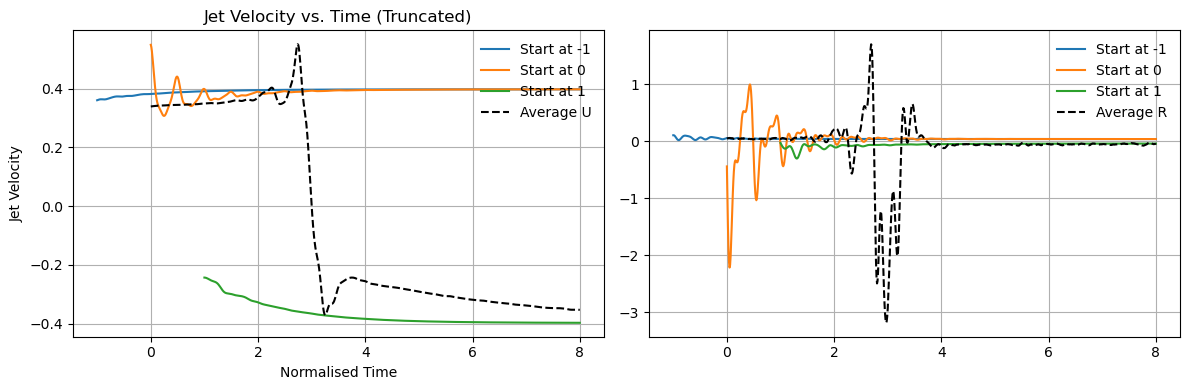

In [19]:

# average_U = average_U[399:]  # Ensure average_U matches the length of x1, x2, x3
# average_R = average_R[399:]  # Ensure average_R matches the length of x1, x2, x3

# average_U = average_U[:len(x1)]  # Ensure average_U matches the length of x1, x2, x3
# average_R = average_R[:len(x1)]  # Ensure average_R matches the length of x1, x2, x3
# ---------------------------------------------------------------
fig, (ax_vel, ax_tau) = plt.subplots(1, 2, figsize=(12, 4))

# ---- Jet Velocity Plot ----
ax_vel.plot(x1, y1, label='Start at -1')
ax_vel.plot(x2, y2, label='Start at 0')
ax_vel.plot(x3, y3, label='Start at 1')
# des_l = len(x1)-300
ax_vel.plot(x2, average_U[199:], label='Average U', linestyle='--', color='black')
# ax_vel.plot(x1, average_U, label='Average U', linestyle='--', color='black')

ax_vel.set_xlabel('Normalised Time')
ax_vel.set_ylabel('Jet Velocity')
ax_vel.set_title('Jet Velocity vs. Time (Truncated)')
ax_vel.legend(frameon=False, loc='upper right')
ax_vel.grid(True)

# ---- Reynolds Stress Plot ----
ax_tau.plot(x1, r1, label='Start at -1')
ax_tau.plot(x2, r2, label='Start at 0')
ax_tau.plot(x3, r3, label='Start at 1')
ax_tau.plot(x2, average_R[199:], label='Average R', linestyle='--', color='black')
# ax_tau.plot(x1, average_R, label='Average R', linestyle='--', color='black')
ax_tau.legend(frameon=False, loc='upper right')
ax_tau.grid(True)

# ---- Shared layout ----
fig.tight_layout()
plt.show()


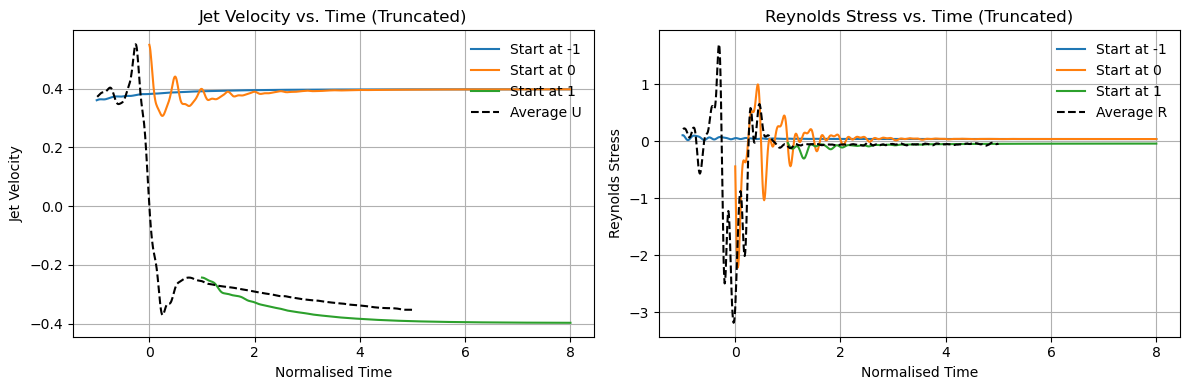

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Generate x values
x = np.arange(0, sims[0].total_time, .01)

# Define y functions for Jet Velocity (U_History)
y1 = sims[3].U_History    # Starts at x = -1
y2 = sims[4].U_History    # Starts at x = 0
y3 = sims[5].U_History    # Starts at x = 1

y1 = y1[9::10]  # Downsample for better performance
y2 = y2[9::10]  # Downsample for better performance
y3 = y3[9::10]  # Downsample for better performance

# Define y functions for Reynolds Stress (R_History)
r1 = sims[3].R_History
r2 = sims[4].R_History
r3 = sims[5].R_History

r1 = r1[9::10]  # Downsample for better performance
r2 = r2[9::10]  # Downsample for better performance
r3 = r3[9::10]  # Downsample for better performance

# Shift x arrays
x1 = x - 1
x2 = x
x3 = x + 1

# Define the common maximum endpoint
x_max = 8
x_min = -1

# Truncate arrays to only include values <= x_max
mask1 = x1 <= x_max
mask2 = x2 <= x_max
mask3 = x3 <= x_max

x1, y1, r1 = x1[mask1], y1[mask1], r1[mask1]
x2, y2, r2 = x2[mask2], y2[mask2], r2[mask2]
x3, y3, r3 = x3[mask3], y3[mask3], r3[mask3]

# ---------------------------------------------------------------
# Prepare black average lines
# ---------------------------------------------------------------

avgU = np.asarray(average_U[199:])
avgR = np.asarray(average_R[199:])

# Make sure average arrays match the available x2 length
n_avg = min(len(x2), len(avgU), len(avgR))

x_avg = x2[:n_avg]
avgU = avgU[:n_avg]
avgR = avgR[:n_avg]

# ---------------------------------------------------------------
# Find where Average U crosses U = 0
# ---------------------------------------------------------------

sign_changes = np.where(np.diff(np.sign(avgU)) != 0)[0]

if len(sign_changes) > 0:
    # Use the first zero crossing
    idx = sign_changes[0]

    # Linear interpolation for a cleaner zero-crossing time
    x_a, x_b = x_avg[idx], x_avg[idx + 1]
    y_a, y_b = avgU[idx], avgU[idx + 1]

    x_zero = x_a - y_a * (x_b - x_a) / (y_b - y_a)
else:
    # Fallback: use the point closest to zero
    idx = np.argmin(np.abs(avgU))
    x_zero = x_avg[idx]

# Shift black curves so Average U crosses zero at x = 0
x_avg_aligned = x_avg - x_zero

# Truncate black curves so nothing appears before x = -1 or after x = 8
mask_avg = (x_avg_aligned >= x_min) & (x_avg_aligned <= x_max)

x_avg_plot = x_avg_aligned[mask_avg]
avgU_plot = avgU[mask_avg]
avgR_plot = avgR[mask_avg]

# ---------------------------------------------------------------
fig, (ax_vel, ax_tau) = plt.subplots(1, 2, figsize=(12, 4))

# ---- Jet Velocity Plot ----
ax_vel.plot(x1, y1, label='Start at -1')
ax_vel.plot(x2, y2, label='Start at 0')
ax_vel.plot(x3, y3, label='Start at 1')

ax_vel.plot(
    x_avg_plot,
    avgU_plot,
    label='Average U',
    linestyle='--',
    color='black'
)

ax_vel.set_xlabel('Normalised Time')
ax_vel.set_ylabel('Jet Velocity')
ax_vel.set_title('Jet Velocity vs. Time (Truncated)')
ax_vel.legend(frameon=False, loc='upper right')
ax_vel.grid(True)

# ---- Reynolds Stress Plot ----
ax_tau.plot(x1, r1, label='Start at -1')
ax_tau.plot(x2, r2, label='Start at 0')
ax_tau.plot(x3, r3, label='Start at 1')

ax_tau.plot(
    x_avg_plot,
    avgR_plot,
    label='Average R',
    linestyle='--',
    color='black'
)

ax_tau.set_xlabel('Normalised Time')
ax_tau.set_ylabel('Reynolds Stress')
ax_tau.set_title('Reynolds Stress vs. Time (Truncated)')
ax_tau.legend(frameon=False, loc='upper right')
ax_tau.grid(True)

# ---- Shared layout ----
fig.tight_layout()
plt.show()